In [1]:
import numpy as np
import matplotlib.pyplot as plt
import timeit

## NumPy

- Efficient and powerful library of arrays
- NumPy arrays are more efficient than Python lists as they are stored in a contiguous block of memory.
- Many functions are available for mathematical operations, linear algebra, and so on.

### Resources:

- Beginner: [Numpy official tutorial](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [Official Numpy Quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- [A visual guide to Numpy](https://jalammar.github.io/visual-numpy/)
- Somewhat advanced: [Nicolas P. Rougier's tutorial](https://github.com/rougier/numpy-tutorial?tab=readme-ov-file)
- [M Scott Shell's notes](https://sites.engineering.ucsb.edu/~shell/che210d/numpy.pdf)
- Harris, C. R. et al. Array Programming with NumPy. Nature 2020, 585 (7825), 357–362. https://doi.org/10.1038/s41586-020-2649-2.



## A neat summary of core numpy methods

![](numpy.webp)


Source: Harris et al., Nature (2020). See above

### Defining arrays

In [34]:
# 1D python list
foo = [1, 2, 3, 4, 5, 6]

# a use case: finding mean of a list of numbers
# using only python
sum = 0
for i in foo:
    sum = sum+i
print(sum/len(foo))

# using numpy
arr1 = np.array(foo)
# type(arr1)
# print(arr1,arr1[2])
print(f'Mean = {arr1.mean()}, sum = {arr1.sum()}')
# arr1.std()


3.5
Mean = 3.5, sum = 21


In [43]:
# 2D array
arr2 = [[1, 2, 3], [4, 5, 6]]
arr2[0][1]
arr2 = np.array([[1, 2, 3], [4, 5, 6]])

print(arr2)
print(arr2[0,1])

2

[[1 2 3]
 [4 5 6]]
2


### Array attributes

In [4]:
print(arr2)
print(arr2.shape) #shape of the array
print(arr2.dtype)  # data type
print(arr2.size) # size of the array
print(arr2.ndim)  # number of dimensions

[[1 2 3]
 [4 5 6]]
(2, 3)
int64
6
2


In [51]:
# 2d arrays in python
a = []
# for i in range(2):
#     a.append(i)
# a
for i in range(2):
    b = []
    for j in range(2):
        b.append(j)
    a.append(b)
    # break
print(a)
# np.array(range(10))
np.arange(10)
# numpy
np.arange(2)
a = np.tile(np.arange(3), (3, 2))
print(a)

[[0, 1], [0, 1]]


array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

array([0, 1])

[[0 1 2 0 1 2]
 [0 1 2 0 1 2]
 [0 1 2 0 1 2]]


### Initializing arrays

In [52]:
zeros_arr = np.zeros((3, 3))
zeros_arr

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [7]:
ones_arr = np.ones((2, 4))
ones_arr

array([[1., 1., 1., 1.],
       [1., 1., 1., 1.]])

In [57]:
full_arr = np.full((3,3), 1.2)
full_arr

array([[1.2, 1.2, 1.2],
       [1.2, 1.2, 1.2],
       [1.2, 1.2, 1.2]])

In [9]:
identity_matrix = np.eye(3)
identity_matrix

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

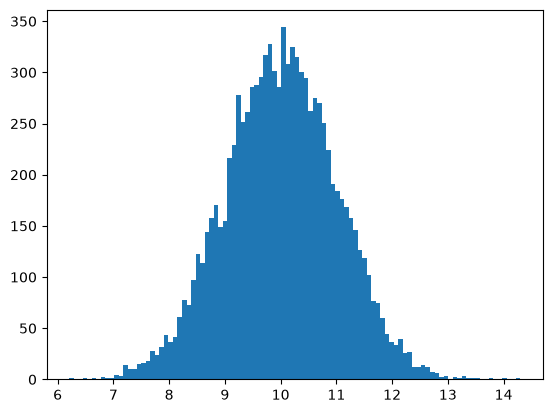

In [63]:
# Array with random values
# np.random.seed(4)
random_arr = np.random.normal(10,1,10000)
# random_arr = np.random.rand(10000)

plt.hist(random_arr,bins=100)
random_arr;

### Accessing elements

In [11]:
arr = np.array([10, 20, 30, 40, 50])

arr[0]  # first element
arr[-1]  # last element

np.int64(10)

np.int64(50)

In [12]:
# Slicing
arr
arr[1:3]
arr[::2]  # Every second element
arr[:2]

array([10, 20, 30, 40, 50])

array([20, 30])

array([10, 30, 50])

array([10, 20])

In [66]:
# Multi-dimensional arrays
arr2 = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(arr2)
print(arr2[1, 2])
print(arr2[:, 2:].shape) # third column as a column vector
print(arr2[:, 2].shape) # third column as a column vector

[[1 2 3]
 [4 5 6]
 [7 8 9]]
6
(3, 1)
(3,)


## Boolean masking
Select elements using conditions.

In [74]:
x = 3
x == 2
x < 4

False

True

In [76]:
x = np.array([1, 2, 1.1, 0, -2, 3, -4])
x > 0
x < 3
x[x>0]
foo = x[(x > 0) & (x < 3)]
foo
# type(foo)

array([ True,  True,  True, False, False,  True, False])

array([ True,  True,  True,  True,  True, False,  True])

array([1. , 2. , 1.1, 3. ])

array([1. , 2. , 1.1])

## Aggregations with axis
Understand operations along dimensions.

In [16]:
arr = np.array([[1,2,3],[4,5,6]])
print(arr)
arr.mean(axis=0)
arr.mean(axis=1)

[[1 2 3]
 [4 5 6]]


array([2.5, 3.5, 4.5])

array([2., 5.])

## Views vs copies
Slicing usually returns a view.

In [79]:
x = 3
y = 3
id(x)
id(y)

4340198392

4340198392

In [81]:
a = 3
b = a
b 
id(a)
id(b)
b = 4
a, b
id(a)
id(b)

3

4340198392

4340198392

(3, 4)

4340198392

4340198424

In [85]:
a = np.array([1,2,3,4])
b=a.copy()
# b = a
id(a)
id(b)

print(b)
b[0] = 9
b
a

4590202256

4590201680

[1 2 3 4]


array([9, 2, 3, 4])

array([1, 2, 3, 4])

In [19]:
# a = [1,2,3,4]
# foo = []
# for i in a:
#     if i > 2:
#         # print(i)
#         foo.append(i)

# print(foo)

# numpy way
# print(list(range(5)))
a = np.array(range(5))
a
# b = a[:5] # b is a view
b = a[a>2] # b is a copy
b
b[0]=2 
b
a

array([0, 1, 2, 3, 4])

array([3, 4])

array([2, 4])

array([0, 1, 2, 3, 4])

### mathematical operations

In [20]:
arr = np.array([0, np.pi / 2, np.pi])

np.sin(arr)
np.cos(arr)
np.sqrt(arr)
import math
for i in arr:
    math.sqrt(i)

array([0.0000000e+00, 1.0000000e+00, 1.2246468e-16])

array([ 1.000000e+00,  6.123234e-17, -1.000000e+00])

array([0.        , 1.25331414, 1.77245385])

0.0

1.2533141373155001

1.7724538509055159

In [21]:
# element-wise Operations

arr1 = np.array([1, 2, 3])
arr2 = np.array([4, 5, 6])
print("Addition:", arr1 + arr2)
print("Multiplication:", arr1 * arr2)
np.dot(arr1,arr2)

Addition: [5 7 9]
Multiplication: [ 4 10 18]


np.int64(32)

In [22]:
# Broadcasting: operations on arrays of different shapes by expanding one array to match the shape of the other.

arr = np.array([1, 2, 3])
print("Adding 5 to each element:", arr + 5)

Adding 5 to each element: [6 7 8]


### Reshaping and Resizing

In [23]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
arr
# Reshape (2x3 to 3x2)
reshaped_arr = arr.reshape((1,6))
reshaped_arr

arr.resize((3, 2))  # Resize (modifies the array in place)
arr

array([[1, 2, 3],
       [4, 5, 6]])

array([[1, 2, 3, 4, 5, 6]])

array([[1, 2],
       [3, 4],
       [5, 6]])

### Aggregation Functions: to compute summaries of arrays

In [86]:
arr = np.array([10, 20, 3, 4, 5])
arr.sum()
arr.mean()
arr.std()
print(arr.min())
arr.max()
print(arr.argmin())

np.int64(42)

np.float64(8.4)

np.float64(6.280127387243033)

3


np.int64(20)

2


## Vectorization vs loops
NumPy is designed to avoid explicit Python loops.

In the following example:

- `np.sin(x)` operates on the entire array at once
- This internal loop runs in compiled C, not in Python, avoiding Python loop overhead
- much faster execution for large arrays


In [25]:
x = np.linspace(0, 2*np.pi, 50)
np.empty_like(x)
np.ones_like(x)


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [26]:

x = np.linspace(0, 2*np.pi, 10000)

def loop_version(x):
    y = np.empty_like(x)
    for i in range(len(x)):
        y[i] = np.sin(x[i])
    return y

def vectorized_version(x):
    return np.sin(x)

# Run loop_version(x) `loop_num` times, measure the total execution time, and return that (in seconds)

loop_num = 10

print('Loop version')
t_loop = timeit.timeit(lambda: loop_version(x), number=loop_num)
t_vector = timeit.timeit(lambda: vectorized_version(x), number=loop_num)
print(f'Loop version took {t_loop:.6f} seconds, while the vectorized version took {t_vector:.6f} seconds, making it about {int(t_loop/t_vector)} times faster.')


Loop version
Loop version took 0.022824 seconds, while the vectorized version took 0.000618 seconds, making it about 36 times faster.
